In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../../course_assignments/homework8/state_data.csv")
print(data.shape) #52 rows 4 cols
print(data.head(5))
print(data.tail(5))
#cols are different catagories of data(state, latitude, longitue and name)
#first state is alaska, last is wyoming, there are more entries cuz the dataset includes non-states dc and puerto rico
avglat = data["latitude"].median()
avglong = data["longitude"].median()
distlat = []
distlong = []
for i in data["latitude"]:
    distlat.append(np.absolute(i-avglat))
for j in data["latitude"]:
    distlong.append(np.absolute(j-avglong))
data["distlat"] = distlat
data["distlong"] = distlong

print(avglat,avglong,data.shape) #52 rows 6 colsnow the shape has 2 extra columns which is what we wanted :)
print(data["name"][np.argmin(data["distlat"])],f"{np.min(data["distlat"]):.2f}")
print(data["name"][np.argmax(data["distlat"])],f"{np.max(data["distlat"]):.2f}")
print(data["name"][np.argmin(data["distlong"])],f"{np.min(data["distlong"]):.2f}")
print(data["name"][np.argmax(data["distlong"])],f"{np.max(data["distlong"]):.2f}")
print(data.describe())#it returned a ton of different info but did a lot of statistics for us like the standard deviation.

(52, 4)
  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming
39.4355155 -89.093198 (52, 6)
Colorado 0.11
Alaska 24.15
Puerto Rico 107.31
Alaska 152.68
        latitude   longitude    distlat    distlong
count  52.000000   52.000000  52.000000   52.000000
mean   39.153437  -92.824719   4.815714  128.246635
std     6.967697   19.431647   4.998411    6.967697
min    18.220833 -155.665857   0.114536  107.314031
25%    35.438381 -102.009600   1.564952  124.531579
50%    39.435516  -89.093198   3.890968  128.52871

(51, 8)
   total  speeding  alcohol  not_distracted  no_previous  ins_premium  \
0   18.8     7.332    5.640          18.048       15.040       784.55   
1   18.1     7.421    4.525          16.290       17.014      1053.48   
2   18.6     6.510    5.208          15.624       17.856       899.47   
3   22.4     4.032    5.824          21.056       21.280       827.34   
4   12.0     4.200    3.360          10.920       10.680       878.41   

   ins_losses abbrev  
0      145.08     AL  
1      133.93     AK  
2      110.35     AZ  
3      142.39     AR  
4      165.63     CA  
    total  speeding  alcohol  not_distracted  no_previous  ins_premium  \
46   12.7     2.413    3.429          11.049       11.176       768.95   
47   10.6     4.452    3.498           8.692        9.116       890.03   
48   23.8     8.092    6.664          23.086       20.706       992.61   
49   13.8     4.968    4.554           5.382       11.592       670.31   
50   17.4     7.308    5.568          14.094 

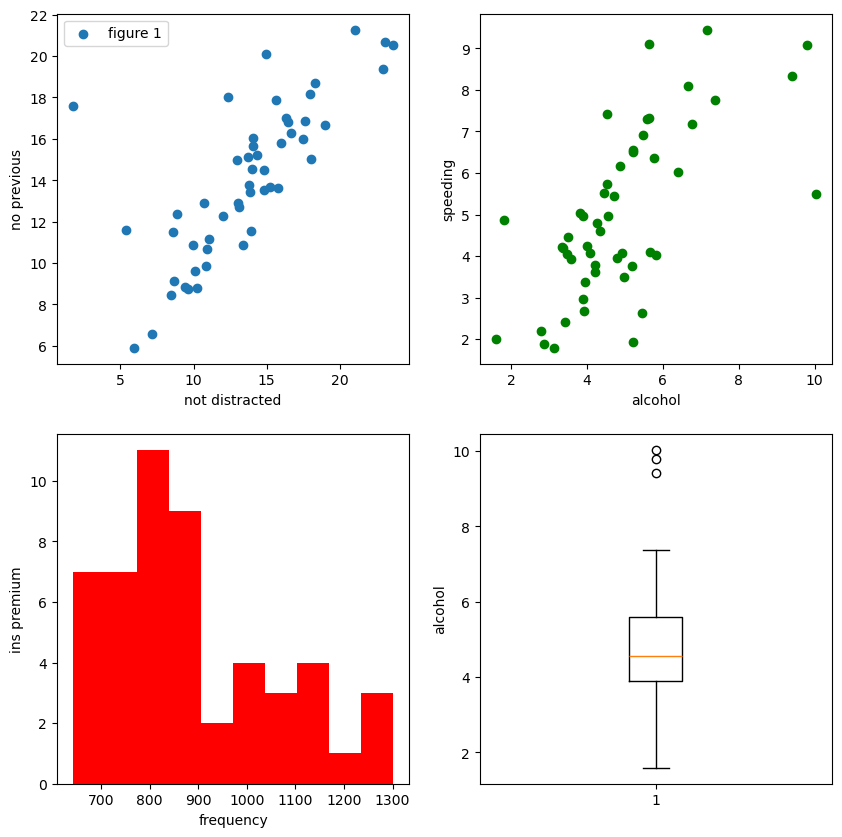

In [3]:
car_crashes = sns.load_dataset("car_crashes")
print(car_crashes.shape) #51 rows 8 cols
print(car_crashes.head(5))
print(car_crashes.tail(5))
print(car_crashes.keys()) #these are the catagories of data they tracked
fig, axes = plt.subplots(2,2,figsize=[10,10])
axes[0,0].scatter(car_crashes["not_distracted"],car_crashes["no_previous"])
axes[0,1].scatter(car_crashes["alcohol"],car_crashes["speeding"],color = "green")
axes[1,0].hist(car_crashes["ins_premium"],color = "red")
axes[1,1].boxplot(car_crashes["alcohol"])
# print(car_crashes)
axes[0,0].set_xlabel("not distracted")
axes[0,1].set_xlabel("alcohol")
axes[1,0].set_xlabel("frequency")
axes[0,0].set_ylabel("no previous")
axes[0,1].set_ylabel("speeding")
axes[1,0].set_ylabel("ins premium")
axes[1,1].set_ylabel("alcohol")
axes[0,0].legend(["figure 1"])
plt.show()
#the top left plot shows there is a positive correlation between no_previous and not distracted
#the top right shows a positive correlation between alcohol and speeding
#the bottom left shows most people had a low amount of insurance premium
#the bottom right shows the range of how much people were drinking